In [12]:
import mlflow
import torch
import os
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

mlflow.set_tracking_uri(f"sqlite:///{os.path.abspath('../../mlflow.db')}")

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = datasets.CIFAR10(root='../../datasets', train = True, download = True, transform=transform)
test_dataset = datasets.CIFAR10(root = '../../datasets', train = False, download = True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

c:\miniconda3\envs\aio\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [14]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=0, stride=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=0, stride=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(nn.Flatten(), nn.Linear(2304, 512), nn.ReLU() , nn.Dropout(0.2), nn.Linear(512, 10))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        return x



Epoch 00 | train_loss: 1.3134 | val_loss: 1.0162 | val_acc: 0.6437
Epoch 01 | train_loss: 0.9859 | val_loss: 0.9342 | val_acc: 0.6701
Epoch 02 | train_loss: 0.8455 | val_loss: 0.8207 | val_acc: 0.7190
Epoch 03 | train_loss: 0.7545 | val_loss: 0.7682 | val_acc: 0.7375
Epoch 04 | train_loss: 0.6812 | val_loss: 0.7915 | val_acc: 0.7242
Epoch 05 | train_loss: 0.6173 | val_loss: 0.7356 | val_acc: 0.7505
Epoch 06 | train_loss: 0.5605 | val_loss: 0.7267 | val_acc: 0.7571
Epoch 07 | train_loss: 0.5026 | val_loss: 0.7484 | val_acc: 0.7531
Epoch 08 | train_loss: 0.4630 | val_loss: 0.8151 | val_acc: 0.7427
Epoch 09 | train_loss: 0.4154 | val_loss: 0.7592 | val_acc: 0.7591
Epoch 10 | train_loss: 0.3806 | val_loss: 0.7812 | val_acc: 0.7584
Epoch 11 | train_loss: 0.3480 | val_loss: 0.8493 | val_acc: 0.7505
Epoch 12 | train_loss: 0.3152 | val_loss: 0.8668 | val_acc: 0.7546
Epoch 13 | train_loss: 0.2854 | val_loss: 0.8797 | val_acc: 0.7489
Epoch 14 | train_loss: 0.2617 | val_loss: 0.9193 | val_acc: 0.

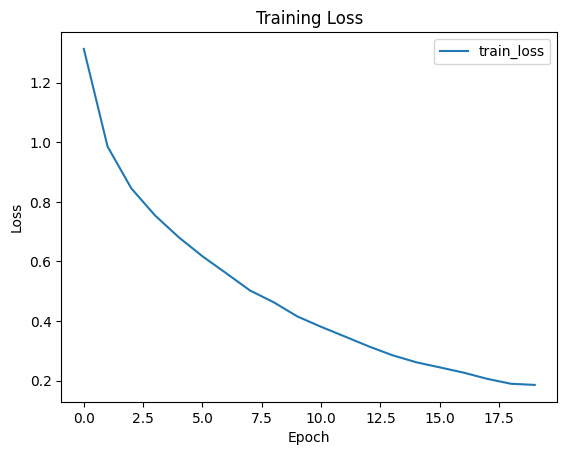

In [15]:
mlflow.set_experiment("cifar-10")

with mlflow.start_run(run_name="cnn-2layers"):
    mlflow.log_params({
        "shape_trace": "(3,32,32)→(32,30,30)→(32,15,15)→(64,13,13)→(64,6,6)→2304→512→10",
        "architecture": "Conv2d-BN-ReLU-MaxPool x2 + FC-ReLU-Dropout-FC",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "epochs": 20,
        "batch_size": 64,
        "dropout": 0.2
    })

    model = Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []

    for epoch in range(20):
        # Training
        model.train()
        train_loss_sum, train_batches = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            train_batches += 1

        # Validation
        model.eval()
        val_loss_sum, val_batches, correct, samples = 0, 0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss_sum += criterion(outputs, labels).item()
                val_batches += 1
                correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
                samples += labels.size(0)

        avg_train_loss = train_loss_sum / train_batches
        avg_val_loss = val_loss_sum / val_batches
        val_accuracy = correct / samples
        train_losses.append(avg_train_loss)

        mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("val_accuracy", val_accuracy, step=epoch)
        print(f"Epoch {epoch:02d} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f} | val_acc: {val_accuracy:.4f}")

    # Final pass for confusion matrix
    model.eval()
    preds, true = [], []

    correct = 0
    samples = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predicted = torch.argmax(model(images), dim=1)
            correct += (predicted == labels).sum().item()
            samples += labels.size(0)
            preds.extend(predicted.tolist())
            true.extend(labels.tolist())

    final_accuracy = correct / samples
    mlflow.log_metric("test_accuracy", final_accuracy)
    print(f"Final test accuracy: {final_accuracy:.4f}")

    fig, ax = plt.subplots()
    ax.plot(train_losses, label="train_loss")
    ax.set_title("Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    mlflow.log_figure(fig, "train_loss.png")
    plt.show()

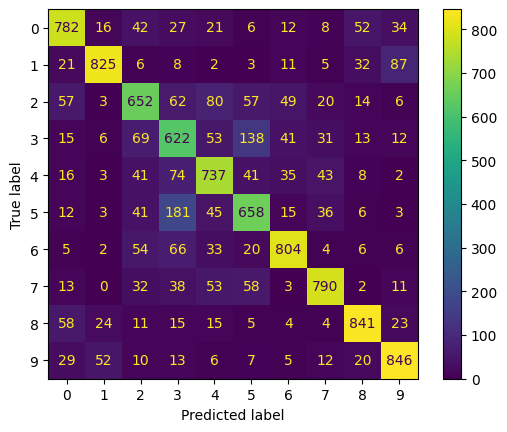

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
disp.plot()
plt.show()
